In [187]:
import scanpy as sc
import decoupler as dc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import gseapy as gp
import textwrap


# Fig. S2a
DE testing between microglia from cortex/hippocampus -- Trem2 vs. 8-cube B6

In [181]:
trem2_mac = sc.read_h5ad('/dfs10/bio/erebboah/parse_pipeline/igvf_015/processed/CortexHippocampus/Trem2_CortexHippocampus_adata_annotated.h5ad')
trem2_mac = trem2_mac[trem2_mac.obs['celltype'] == 'microglial cell'].copy()


In [182]:
b6_mac = sc.read_h5ad('/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/annotated/Microglia_CortexHippocampus.h5ad')
b6_mac = b6_mac[b6_mac.obs['Genotype'] == 'B6J'].copy()



In [183]:
## Downsample B6 data to match # Trem2 cells...?

In [184]:
# import numpy as np

# # Set seed for reproducibility (optional)
# np.random.seed(42)

# # Downsample to 1077 cells
# b6_mac_downsampled = b6_mac[np.random.choice(b6_mac.obs_names, size=1077, replace=False)].copy()
# a

In [188]:
def run_deseq_on_pseudobulk(trem2_adata, b6_adata, layer='raw_counts'):
    # Pseudobulk: trem2
    trem2_pdata = dc.pp.pseudobulk(
        trem2_adata,
        sample_col='lab_sample_id',
        groups_col=None,
        layer=layer,
        mode='sum'
    )
    dc.pp.filter_samples(trem2_pdata, min_cells=10, min_counts=1000, inplace=True)

    # Pseudobulk: b6
    b6_pdata = dc.pp.pseudobulk(
        b6_adata,
        sample_col='lab_sample_id',
        groups_col=None,
        layer=layer,
        mode='sum'
    )
    dc.pp.filter_samples(b6_pdata, min_cells=10, min_counts=1000, inplace=True)

    # Merge
    merged_adata = ad.concat([trem2_pdata, b6_pdata], axis=0)

    # Data and metadata
    df_pbulk = merged_adata.to_df()
    metadata = merged_adata.obs[['lab_sample_id', 'Sex', 'Genotype']].copy()
    metadata = metadata.drop_duplicates()
    metadata.set_index('lab_sample_id', inplace=True)
    metadata = metadata.reindex(df_pbulk.index)

    # DESeq2
    dds = DeseqDataSet(
        counts=df_pbulk,
        metadata=metadata,
        design_factors=['Sex', 'Genotype'],
        ref_level=['Genotype', 'B6J'],
        refit_cooks=True,
        quiet=True
    )
    dds.deseq2()

    # Results
    stat_res = DeseqStats(dds, contrast=['Genotype', 'TREM2R47HNSS_HO', 'B6J'])
    stat_res.summary()
    stat_res.lfc_shrink(coeff='Genotype[T.TREM2R47HNSS_HO]')

    return stat_res


In [189]:
stat_res = run_deseq_on_pseudobulk(trem2_mac, b6_mac, layer='raw_counts')


/tmp/ipykernel_3388814/1108507745.py:33: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
  dds = DeseqDataSet(
/tmp/ipykernel_3388814/1108507745.py:33: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Running Wald tests...
... done in 3.30 seconds.



Log2 fold change & Wald test p-value: Genotype TREM2R47HNSS_HO vs B6J
            baseMean  log2FoldChange     lfcSE       stat        pvalue  \
gene_name                                                                 
Gm20772     0.000000             NaN       NaN        NaN           NaN   
Grk6       15.065013        0.004393  0.245676   0.017880  9.857347e-01   
Pot1b      41.759432        2.169137  0.148378  14.618983  2.125518e-48   
Gm38186     0.436515       -0.846893  1.284296  -0.659421  5.096252e-01   
Gm45740     3.969481       -0.568360  0.483638  -1.175176  2.399241e-01   
...              ...             ...       ...        ...           ...   
Gm54794     0.000000             NaN       NaN        NaN           NaN   
Gm49083     0.866600       -1.175073  1.116657  -1.052313  2.926559e-01   
Acss2os     0.173115        0.288522  1.363813   0.211555  8.324539e-01   
Gpn1        7.308747        0.239017  0.342229   0.698414  4.849181e-01   
Gm26586     0.044243        1.

Fitting MAP LFCs...


Shrunk log2 fold change & Wald test p-value: Genotype[T.TREM2R47HNSS_HO]
            baseMean  log2FoldChange     lfcSE       stat        pvalue  \
gene_name                                                                 
Gm20772     0.000000             NaN       NaN        NaN           NaN   
Grk6       15.065013        0.004234  0.240103   0.017880  9.857347e-01   
Pot1b      41.759432        2.155032  0.148856  14.618983  2.125518e-48   
Gm38186     0.436515       -1.281620  1.453493  -0.659421  5.096252e-01   
Gm45740     3.969481       -0.474558  0.442765  -1.175176  2.399241e-01   
...              ...             ...       ...        ...           ...   
Gm54794     0.000000             NaN       NaN        NaN           NaN   
Gm49083     0.866600       -1.053700  1.013864  -1.052313  2.926559e-01   
Acss2os     0.173115       -0.599436  1.109934   0.211555  8.324539e-01   
Gpn1        7.308747        0.215238  0.330287   0.698414  4.849181e-01   
Gm26586     0.044243       

... done in 4.64 seconds.



/opt/apps/python/3.10.2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


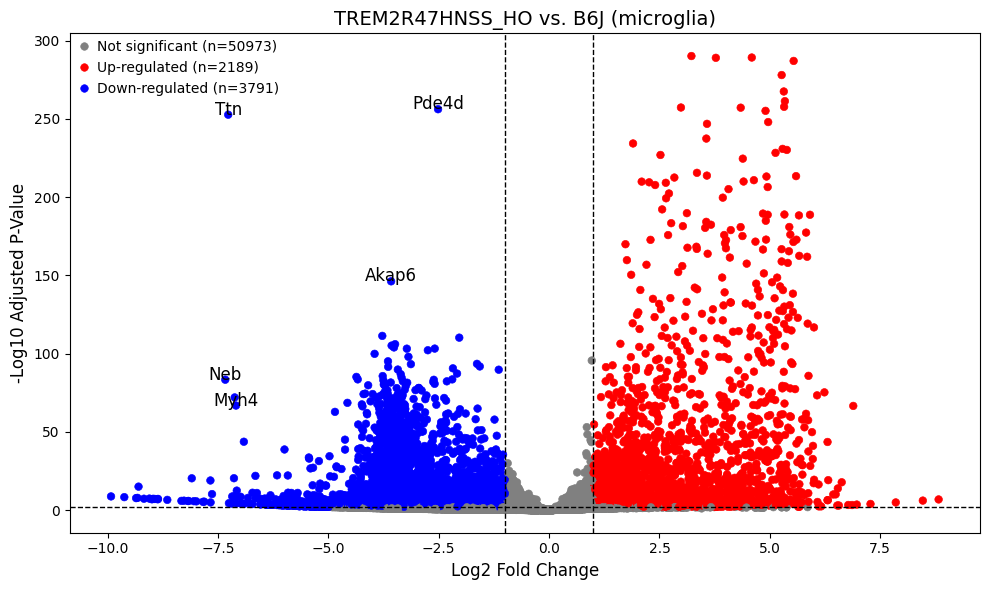

In [218]:
res_df = stat_res.results_df.reset_index()
res_df['-log10_padj'] = -np.log10(res_df['padj'])

# Define thresholds
lfc_thresh = 1
log10_padj_thresh = 2

# Label significance category
def categorize(row):
    if row['-log10_padj'] > log10_padj_thresh and row['log2FoldChange'] > lfc_thresh:
        return 'Up'
    elif row['-log10_padj'] > log10_padj_thresh and row['log2FoldChange'] < -lfc_thresh:
        return 'Down'
    else:
        return 'NotSig'

res_df['sig'] = res_df.apply(categorize, axis=1)

# Count significant genes
n_up = (res_df['sig'] == 'Up').sum()
n_down = (res_df['sig'] == 'Down').sum()
n_notsig = (res_df['sig'] == 'NotSig').sum()

# Create legend labels
sig_label_map = {
    'Up': f'Up-regulated (n={n_up})',
    'Down': f'Down-regulated (n={n_down})',
    'NotSig': f'Not significant (n={n_notsig})'
}

# Map to a new column
res_df['sig_label'] = res_df['sig'].map(sig_label_map)

# Define palette with matching keys
color_map = {
    sig_label_map['Up']: 'red',
    sig_label_map['Down']: 'blue',
    sig_label_map['NotSig']: 'gray'
}


# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=res_df, x='log2FoldChange', y='-log10_padj',
                hue='sig_label', palette=color_map, s=30, edgecolor=None)

# Add dashed threshold lines
plt.axhline(log10_padj_thresh, linestyle='--', color='black', linewidth=1)
plt.axvline(-lfc_thresh, linestyle='--', color='black', linewidth=1)
plt.axvline(lfc_thresh, linestyle='--', color='black', linewidth=1)

# Annotate genes meeting both thresholds
highlight = res_df[(res_df['-log10_padj'] > log10_padj_thresh) & (res_df['log2FoldChange'].abs() > lfc_thresh)]

annotate = res_df[(res_df['-log10_padj'] > 120) & (res_df['log2FoldChange'] < -2)]

# Explicitly label specific genes
extra_genes = ['Neb', 'Myh4']
extra_rows = res_df[res_df['gene_name'].isin(extra_genes)]

# Combine both
annotate = pd.concat([annotate, extra_rows]).drop_duplicates()
    
for _, row in annotate.iterrows():
    plt.text(row['log2FoldChange'], row['-log10_padj'], row['gene_name'], fontsize=12, ha='center')

# Labels and legend
plt.title(f"TREM2R47HNSS_HO vs. B6J (microglia)", fontsize=14)
plt.xlabel("Log2 Fold Change", fontsize=12)
plt.ylabel("-Log10 Adjusted P-Value", fontsize=12)
plt.legend(title=None, loc='upper left')

plt.tight_layout()
plt.savefig('../supp_fig2/microglia_trem2_vs_b6_raw_counts.png', dpi=300, bbox_inches='tight')


# After your plt.show() for the raw_counts volcano
xlim_raw = plt.xlim()
ylim_raw = plt.ylim()

plt.show()


In [176]:
up = res_df[res_df['sig'] == 'Up']
down = res_df[res_df['sig'] == 'Down']

In [177]:
enr = gp.enrichr(
    gene_list=up['gene_name'].tolist(),
    organism='Mouse', 
    gene_sets=['Reactome_2022', 'GO_Biological_Process_2023']
)
df = enr.results
df = df.sort_values(by="Adjusted P-value", ascending=True)

df['-log10(Adjusted P-value)'] = -np.log10(df['Adjusted P-value'])
df = df[df['Adjusted P-value'] <= 0.05]
df = df.head(4)

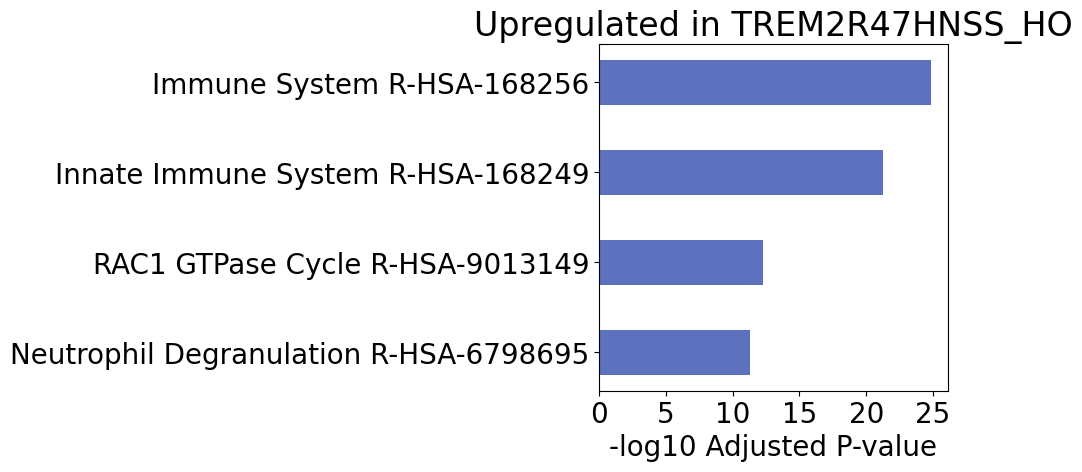

In [178]:
# Plot
plt.figure(figsize=(4.5, 4.5))
plt.barh(df['Term'], df['-log10(Adjusted P-value)'], color='#5C72BF', height = 0.5)
plt.xlabel('-log10 Adjusted P-value', fontsize=20)
plt.ylabel('')
plt.title('Upregulated in TREM2R47HNSS_HO', fontsize = 24)
plt.gca().invert_yaxis() 
plt.yticks(fontsize=20) 
plt.xticks(fontsize=20)

plt.show()

In [179]:
enr = gp.enrichr(
    gene_list=down['gene_name'].tolist(),
    organism='Mouse', 
    gene_sets=['Reactome_2022', 'GO_Biological_Process_2023']
)
df = enr.results
df = df.sort_values(by="Adjusted P-value", ascending=True)

df['-log10(Adjusted P-value)'] = -np.log10(df['Adjusted P-value'])
df = df[df['Adjusted P-value'] <= 0.05]
df = df.head(4)

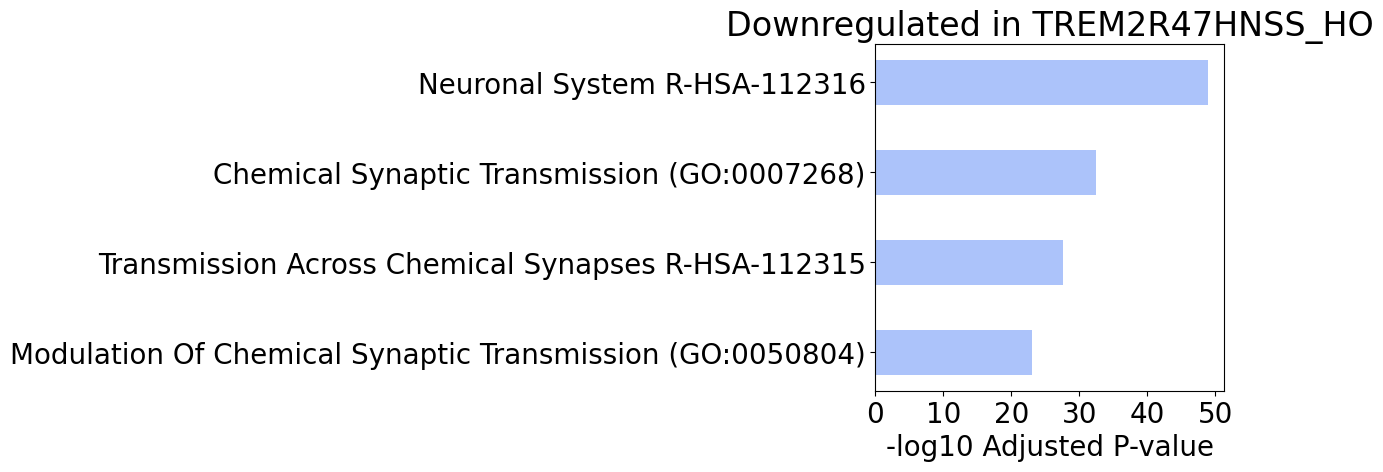

In [180]:
# Plot
plt.figure(figsize=(4.5, 4.5))
plt.barh(df['Term'], df['-log10(Adjusted P-value)'], color='#ACC3FA', height = 0.5)
plt.xlabel('-log10 Adjusted P-value', fontsize=20)
plt.ylabel('')
plt.title('Downregulated in TREM2R47HNSS_HO', fontsize = 24)
plt.gca().invert_yaxis() 
plt.yticks(fontsize=20) 
plt.xticks(fontsize=20)

plt.show()

# Fig. S2b
Expression patterns overall 

In [15]:
adata = sc.read_h5ad('/dfs10/bio/erebboah/parse_pipeline/igvf_015/adata.h5ad')


In [16]:
adata

AnnData object with n_obs × n_vars = 251232 × 56953
    obs: 'lab_sample_id', 'sample', 'plate', 'subpool', 'SampleType', 'Tissue', 'Sex', 'Age', 'Genotype', 'subpool_type', 'Protocol', 'Chemistry', 'bc', 'bc1_sequence', 'bc2_sequence', 'bc3_sequence', 'bc1_well', 'bc2_well', 'bc3_well', 'Row', 'Column', 'well_type', 'Mouse_Tissue_ID', 'DOB', 'Age_days', 'Body_weight_g', 'Estrus_cycle', 'Dissection_date', 'Dissection_time', 'ZT', 'Dissector', 'Tissue_weight_mg', 'Notes', 'n_genes_by_counts_raw', 'total_counts_raw', 'total_counts_mt_raw', 'pct_counts_mt_raw', 'n_genes_by_counts_cb', 'total_counts_cb', 'total_counts_mt_cb', 'pct_counts_mt_cb', 'doublet_score', 'predicted_doublet', 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency'
    var: 'gene_id', 'gene_name', 'mt'
    obsm: 'gene_expression_encoding'
    layers: 'cellbender_counts', 'raw_counts'

In [36]:
well_to_tiss = well_to_tiss.copy()
well_to_tiss['Column'] = well_to_tiss['bc1_well'].str[1:].astype(int)
column_to_tissue = well_to_tiss.groupby('Column')['Tissue'].unique().str[0]
rename_dict = {
    'DiencephalonPituitary': 'DCPituitary',
    'CortexHippocampus': 'CortexHC',
    'Gastrocnemius': 'Muscle',
    'GonadsMale': 'Gonads'
}

column_to_tissue = column_to_tissue.replace(rename_dict)


In [47]:
def plot_expression_heatmap(df, gene, title, column_to_tissue, filename):
    # make sure we have the gene
    if gene not in df.index:
        raise ValueError(f"'{gene}' not found.")
    
    gene_data = df.loc[gene]
    
    # make an empty df for 96-well plate
    rows = list('ABCDEFGH')
    cols = list(range(1, 13))
    plate_df = pd.DataFrame(0, index=rows, columns=cols)
    
    # fill the df
    for well, expression in gene_data.items():
        row = well[0]
        col = int(well[1:])
        plate_df.at[row, col] = expression
    
    # create hmap
    plt.figure(figsize=(12, 6))
    sns.heatmap(plate_df, annot=True, fmt='.1f', cmap='viridis', cbar=True, linewidths=0.5,
                annot_kws={"size": 10}, cbar_kws={'label': 'Gene Expression'})
    
    if title:
        plt.title(f'{gene} {title}', fontsize=16)
    else:
        plt.title(f'{gene} pseudobulk counts', fontsize=16)
        
    plt.xlabel('Column', fontsize=14)
    plt.ylabel('Row', fontsize=14)
    plt.xticks(ticks=np.arange(12) + 0.5, labels=column_to_tissue.values, rotation=45, fontsize=12)
    plt.yticks(rotation=0, fontsize=12)
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    
    plt.show()

In [40]:
pdata = dc.pp.pseudobulk(
     adata,
     sample_col='bc1_well',
     groups_col=None,
     layer='raw_counts',
     mode='sum'
 )

dc.pp.filter_samples(
    pdata,
    min_cells=10,
    min_counts=1000,
    inplace=True
)


In [41]:
df = pdata.to_df().transpose()

df_log2 = df.applymap(lambda x: np.log2(x + 1))


/tmp/ipykernel_3347842/3340940725.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_log2 = df.applymap(lambda x: np.log2(x + 1))


/tmp/ipykernel_3347842/1098838109.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6.523561956057013' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  plate_df.at[row, col] = expression
/tmp/ipykernel_3347842/1098838109.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5.285402218862249' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  plate_df.at[row, col] = expression
/tmp/ipykernel_3347842/1098838109.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4.523561956057013' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  plate_df.at[row, col] = expression
/tmp/ipykernel_3347842/1098838109.py:17: FutureWarning: Setti

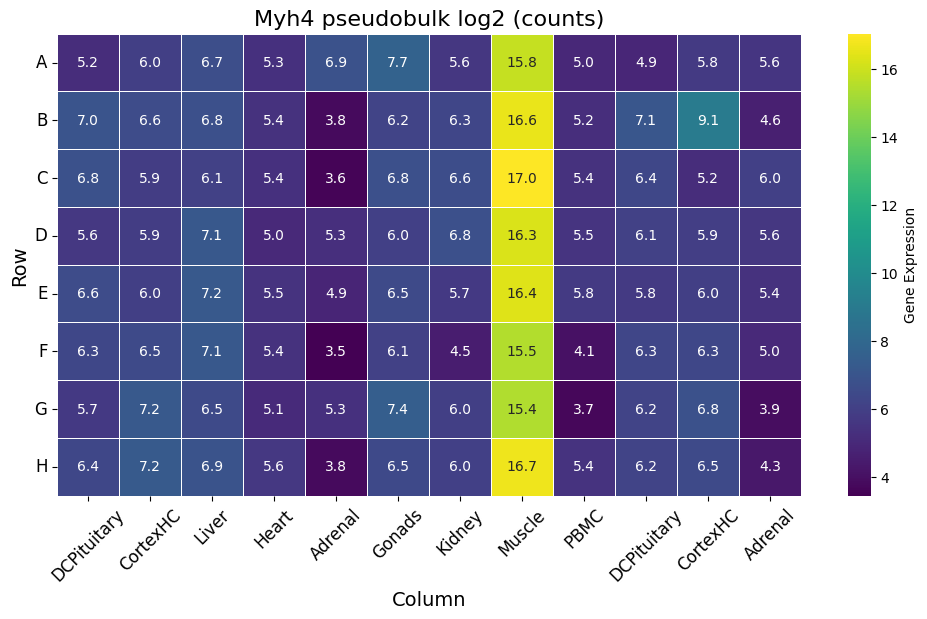

In [50]:
plot_expression_heatmap(df_log2, 'Myh4', 'pseudobulk log2 (counts)', column_to_tissue, '../supp_fig2/Myh4_raw_counts_hmap')


/tmp/ipykernel_3347842/1098838109.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5.20945336562895' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  plate_df.at[row, col] = expression
/tmp/ipykernel_3347842/1098838109.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5.321928094887363' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  plate_df.at[row, col] = expression
/tmp/ipykernel_3347842/1098838109.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.4594316186372973' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  plate_df.at[row, col] = expression
/tmp/ipykernel_3347842/1098838109.py:17: FutureWarning: Setti

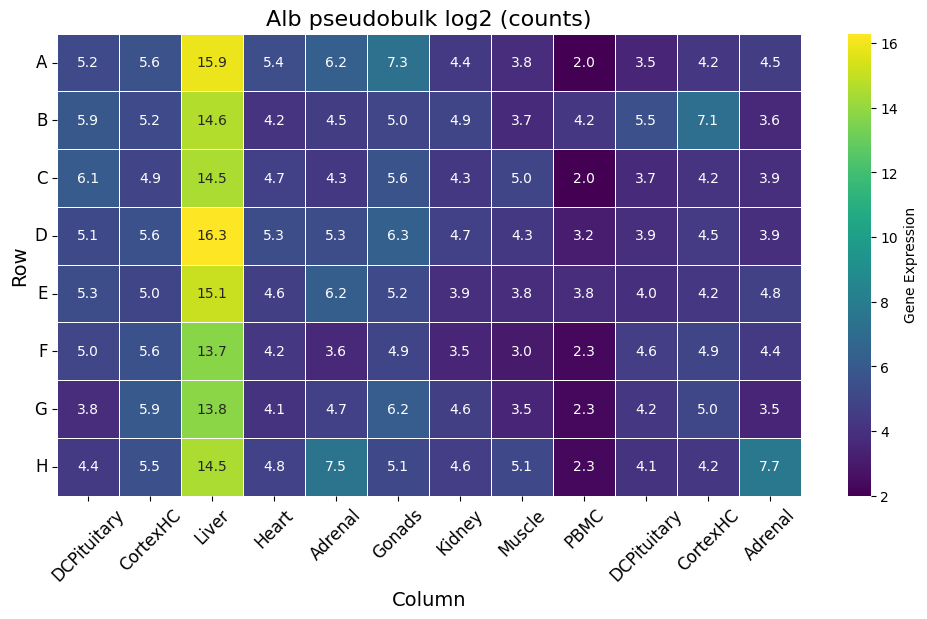

In [51]:
plot_expression_heatmap(df_log2, 'Alb', 'pseudobulk log2 (counts)', column_to_tissue, '../supp_fig2/Alb_raw_counts_hmap')


# Fig. S2d

Same analysis as for a but using cellbender corrected counts

In [191]:
stat_res_cb = run_deseq_on_pseudobulk(trem2_mac, b6_mac, layer='cellbender_counts')


/tmp/ipykernel_3388814/1108507745.py:33: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
  dds = DeseqDataSet(
/tmp/ipykernel_3388814/1108507745.py:33: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Running Wald tests...
... done in 3.25 seconds.

Fitting MAP LFCs...


Log2 fold change & Wald test p-value: Genotype TREM2R47HNSS_HO vs B6J
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_name                                                                   
Gm20772     0.000000             NaN       NaN       NaN       NaN       NaN
Grk6        8.270688        0.214437  0.306434  0.699782  0.484063  0.810677
Pot1b      43.036639       -0.088689  0.151676 -0.584728  0.558730  0.852168
Gm38186     0.000000             NaN       NaN       NaN       NaN       NaN
Gm45740     0.850838        1.724144  1.011579  1.704409  0.088305       NaN
...              ...             ...       ...       ...       ...       ...
Gm54794     0.000000             NaN       NaN       NaN       NaN       NaN
Gm49083     0.156512        1.390343  2.801279  0.496324  0.619666       NaN
Acss2os     0.023923        1.051264  3.306225  0.317965  0.750511       NaN
Gpn1        4.192061        0.325338  0.420704  0.773317  0.439335  0.788874
Gm2658

... done in 4.35 seconds.



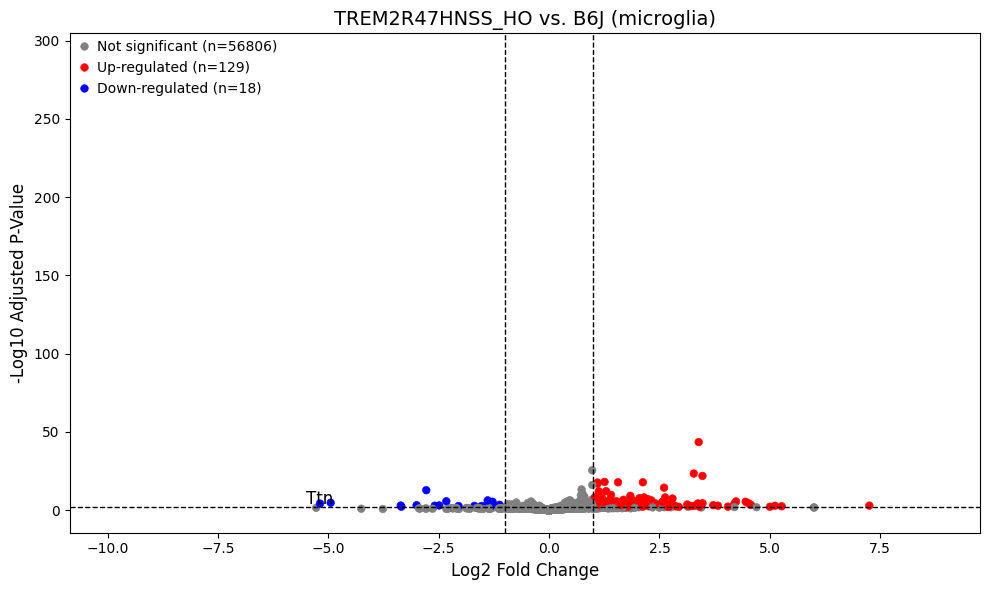

In [219]:
res_df = stat_res_cb.results_df.reset_index()
res_df['-log10_padj'] = -np.log10(res_df['padj'])

# Define thresholds
lfc_thresh = 1
log10_padj_thresh = 2

# Label significance category
def categorize(row):
    if row['-log10_padj'] > log10_padj_thresh and row['log2FoldChange'] > lfc_thresh:
        return 'Up'
    elif row['-log10_padj'] > log10_padj_thresh and row['log2FoldChange'] < -lfc_thresh:
        return 'Down'
    else:
        return 'NotSig'

res_df['sig'] = res_df.apply(categorize, axis=1)

# Count significant genes
n_up = (res_df['sig'] == 'Up').sum()
n_down = (res_df['sig'] == 'Down').sum()
n_notsig = (res_df['sig'] == 'NotSig').sum()

# Create legend labels
sig_label_map = {
    'Up': f'Up-regulated (n={n_up})',
    'Down': f'Down-regulated (n={n_down})',
    'NotSig': f'Not significant (n={n_notsig})'
}

# Map to a new column
res_df['sig_label'] = res_df['sig'].map(sig_label_map)

# Define palette with matching keys
color_map = {
    sig_label_map['Up']: 'red',
    sig_label_map['Down']: 'blue',
    sig_label_map['NotSig']: 'gray'
}


# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=res_df, x='log2FoldChange', y='-log10_padj',
                hue='sig_label', palette=color_map, s=30, edgecolor=None)

# Add dashed threshold lines
plt.axhline(log10_padj_thresh, linestyle='--', color='black', linewidth=1)
plt.axvline(-lfc_thresh, linestyle='--', color='black', linewidth=1)
plt.axvline(lfc_thresh, linestyle='--', color='black', linewidth=1)

# Annotate genes meeting both thresholds
highlight = res_df[(res_df['-log10_padj'] > log10_padj_thresh) & (res_df['log2FoldChange'].abs() > lfc_thresh)]

# annotate = res_df[(res_df['-log10_padj'] > 20) & (res_df['log2FoldChange'].abs() > 10)]

# Explicitly label specific genes
extra_genes = ['Ttn']#, 'Neb', 'Pde4b', 'Akap6', 'Myh4']
extra_rows = res_df[res_df['gene_name'].isin(extra_genes)]

# Combine both
annotate = extra_rows #pd.concat([annotate, extra_rows]).drop_duplicates()
    
for _, row in annotate.iterrows():
    plt.text(row['log2FoldChange'], row['-log10_padj'], row['gene_name'], fontsize=12, ha='center')

# Labels and legend
plt.title(f"TREM2R47HNSS_HO vs. B6J (microglia)", fontsize=14)
plt.xlabel("Log2 Fold Change", fontsize=12)
plt.ylabel("-Log10 Adjusted P-Value", fontsize=12)
plt.legend(title=None, loc='upper left')
plt.xlim(xlim_raw)
plt.ylim(ylim_raw)

plt.tight_layout()
plt.savefig('../supp_fig2/microglia_trem2_vs_b6_cellbender_counts.png', dpi=300, bbox_inches='tight')

plt.show()


In [199]:
up = res_df[res_df['sig'] == 'Up']
down = res_df[res_df['sig'] == 'Down']

In [196]:
enr = gp.enrichr(
    gene_list=up['gene_name'].tolist(),
    organism='Mouse', 
    gene_sets=['Reactome_2022', 'GO_Biological_Process_2023']
)
df = enr.results
df = df.sort_values(by="Adjusted P-value", ascending=True)

df['-log10(Adjusted P-value)'] = -np.log10(df['Adjusted P-value'])
df = df[df['Adjusted P-value'] <= 0.05]
df = df.head(4)

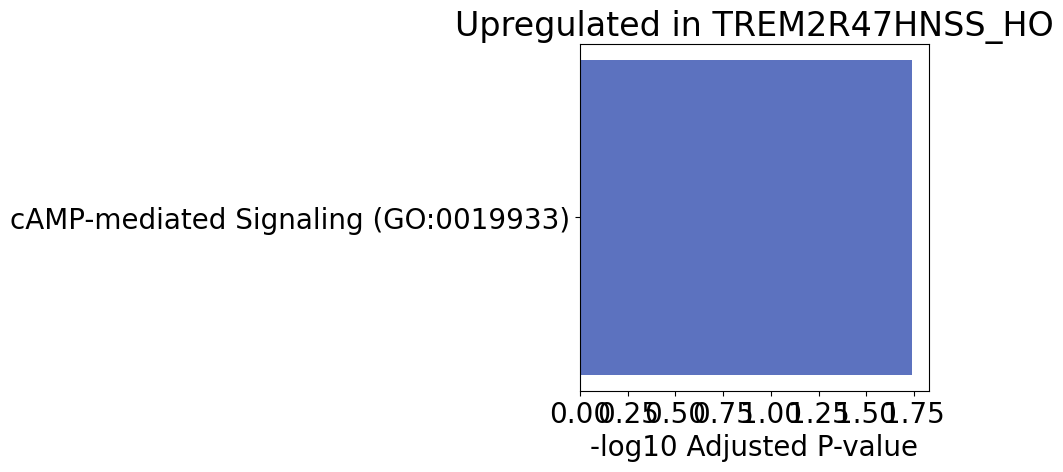

In [197]:
# Plot
plt.figure(figsize=(4.5, 4.5))
plt.barh(df['Term'], df['-log10(Adjusted P-value)'], color='#5C72BF', height = 0.5)
plt.xlabel('-log10 Adjusted P-value', fontsize=20)
plt.ylabel('')
plt.title('Upregulated in TREM2R47HNSS_HO', fontsize = 24)
plt.gca().invert_yaxis() 
plt.yticks(fontsize=20) 
plt.xticks(fontsize=20)

plt.show()

In [203]:
enr = gp.enrichr(
    gene_list=down['gene_name'].tolist(),
    organism='Mouse', 
    gene_sets=['Reactome_2022', 'GO_Biological_Process_2023']
)
df = enr.results
df = df.sort_values(by="Adjusted P-value", ascending=True)

df['-log10(Adjusted P-value)'] = -np.log10(df['Adjusted P-value'])
df = df[df['Adjusted P-value'] <= 0.05]
df = df.head(4)

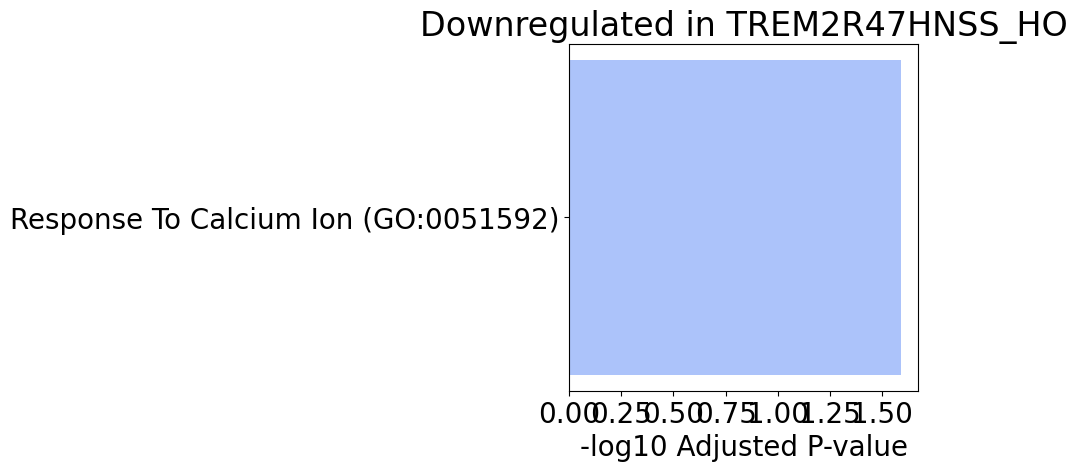

In [204]:
# Plot
plt.figure(figsize=(4.5, 4.5))
plt.barh(df['Term'], df['-log10(Adjusted P-value)'], color='#ACC3FA', height = 0.5)
plt.xlabel('-log10 Adjusted P-value', fontsize=20)
plt.ylabel('')
plt.title('Downregulated in TREM2R47HNSS_HO', fontsize = 24)
plt.gca().invert_yaxis() 
plt.yticks(fontsize=20) 
plt.xticks(fontsize=20)

plt.show()

# Fig. S2e

In [44]:
pdata_cb = dc.pp.pseudobulk(
     adata,
     sample_col='bc1_well',
     groups_col=None,
     layer='cellbender_counts',
     mode='sum'
 )

dc.pp.filter_samples(
    pdata_cb,
    min_cells=10,
    min_counts=1000,
    inplace=True
)

df_cb= pdata_cb.to_df().transpose()

df_log2_cb = df_cb.applymap(lambda x: np.log2(x + 1))



/tmp/ipykernel_3347842/2866480958.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_log2_cb = df_cb.applymap(lambda x: np.log2(x + 1))


/tmp/ipykernel_3347842/1098838109.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.4594316186372973' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  plate_df.at[row, col] = expression
/tmp/ipykernel_3347842/1098838109.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.584962500721156' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  plate_df.at[row, col] = expression
/tmp/ipykernel_3347842/1098838109.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.584962500721156' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  plate_df.at[row, col] = expression
/tmp/ipykernel_3347842/1098838109.py:17: FutureWarning: Sett

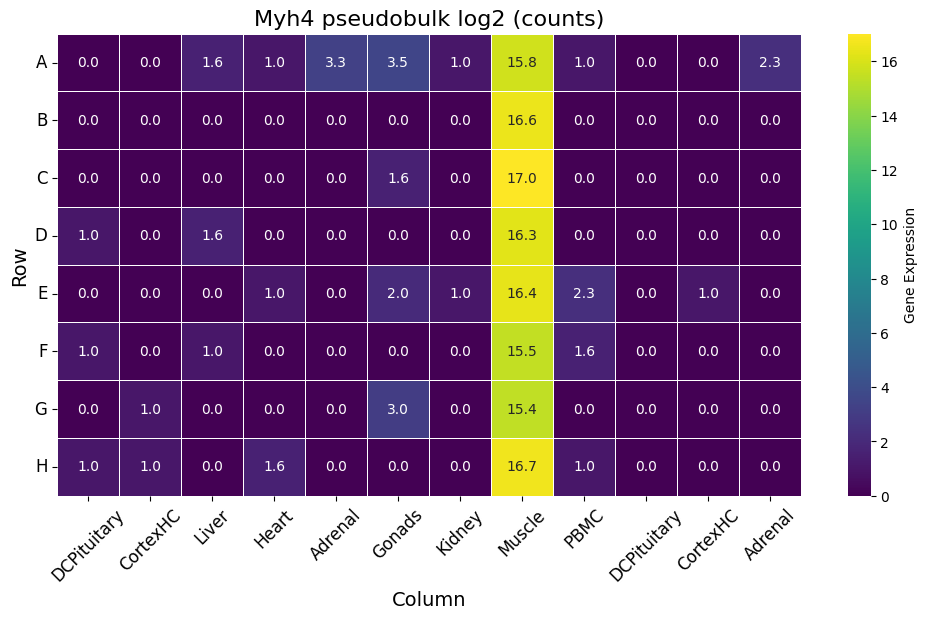

In [52]:
plot_expression_heatmap(df_log2_cb, 'Myh4', 'pseudobulk log2 (counts)', column_to_tissue, '../supp_fig2/Myh4_corrected_counts_hmap')


/tmp/ipykernel_3347842/1098838109.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4.459431618637297' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  plate_df.at[row, col] = expression
/tmp/ipykernel_3347842/1098838109.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.4594316186372973' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  plate_df.at[row, col] = expression
/tmp/ipykernel_3347842/1098838109.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '16.282418809183312' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  plate_df.at[row, col] = expression
/tmp/ipykernel_3347842/1098838109.py:17: FutureWarning: Set

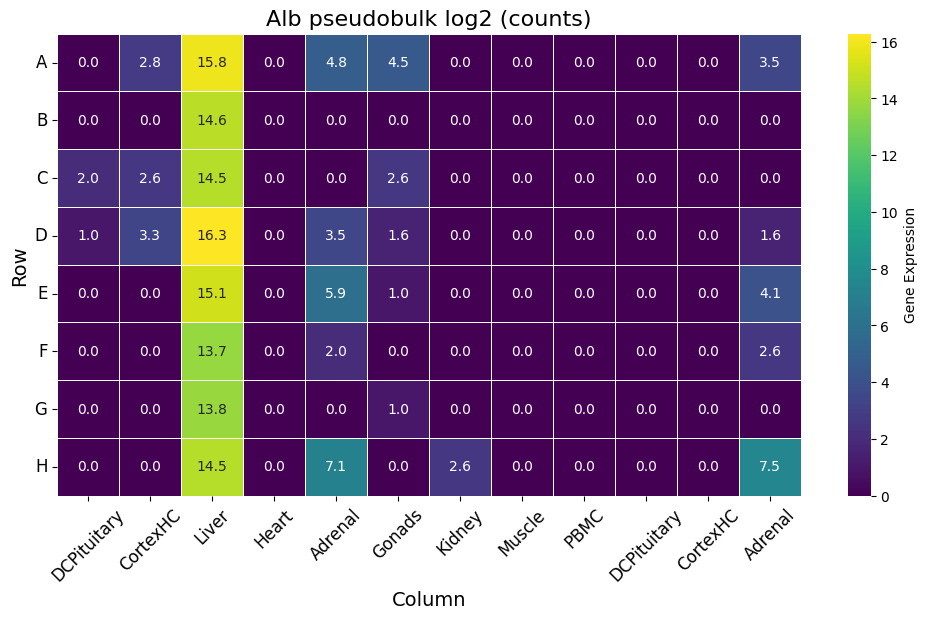

In [53]:
plot_expression_heatmap(df_log2_cb, 'Alb', 'pseudobulk log2 (counts)', column_to_tissue, '../supp_fig2/Alb_corrected_counts_hmap')
